# [Bacterial Colony Growth](@id Bacteries)

In this example, we are going to create a bacterial model and grow a colony using it.

 - The implementation of the force interaction dynamics is the one presented by [Volfson et al. (2008)](https://www.pnas.org/doi/abs/10.1073/pnas.0706805105)
 - We use GPU accelerated dynamics

As described in other models, it is advised that the models are constructed by parts to avoid having to find bugs in a very complex system. Hence, we will split the model in two parts:

 - Forces model
 - Growth model

## Load the packages

In [1]:
using Base.Threads
println("Usando ", nthreads(), " threads 😎")

Usando 15 threads 😎


In [2]:
# import Pkg
# Pkg.activate("../")
# Pkg.instantiate()


In [3]:
# import Pkg; Pkg.add(["Revise", "GLMakie"])

In [4]:
# using Revise
# using CellBasedModels
# using CUDA
# using Distributions
# using GLMakie
# # using GeometryBasics
# import GLMakie: Point3f, Cylinder, Sphere, NoShading #Can be changes to Cairo or CLMakie

In [5]:
import Pkg

# Activa el entorno del proyecto
Pkg.activate("C:/Users/julia/OneDrive/Escritorio/phd/Bacteria_ABM/ABM_CBM/")



# Resuelve y asegura dependencias
Pkg.resolve()
Pkg.instantiate()


# Carga los paquetes de forma ordenada
using Revise
using CellBasedModels
ENV["JULIA_CUDA_USE_BINARYBUILDER"] = false  # (opcional, fuerza compilación local)
using CUDA
CUDA.set_runtime_version!(v"12.2")
using Distributions
using CairoMakie
using JSON

# Importa funciones específicas después
import CairoMakie: Point3f, Cylinder, Sphere, NoShading

CairoMakie.activate!()


  Activating project at `C:\Users\julia\OneDrive\Escritorio\phd\Bacteria_ABM\ABM_CBM`
  No Changes to `C:\Users\julia\OneDrive\Escritorio\phd\Bacteria_ABM\ABM_CBM\Project.toml`
  No Changes to `C:\Users\julia\OneDrive\Escritorio\phd\Bacteria_ABM\ABM_CBM\Manifest.toml`
┌ Info: Configure the active project to use CUDA 12.2; please re-start Julia for this to take effect.
└ @ CUDA C:\Users\julia\.julia\packages\CUDA\jdJ7Z\lib\cudadrv\version.jl:82


## Forces model

We already use the defined forces model that is implemented in CBqodels. This is an exact copy of the rod model that you can find already predefined in `Models/rods.jl`. You can check the `Models` section of the documentation for more details.


In [6]:
rod2D = ABM(2,
    agent = Dict(
            :theta=>Float64,
            :d=>Float64,
            :l=>Float64,
            :fx=>Float64,
            :fy=>Float64,
            :W=>Float64,
        ),    #Local Interaction Parameters

    model = Dict(
            :E=>Float64,
            :eta=>Float64,

        ),        #Global parameters

    agentODE = quote

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin

            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij
            
        end

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg = CBMIntegrators.Heun()
);


### Initialize a coqunity with two bacteries and check forces

In [7]:
com = Community(rod2D,
            N=30,
            dt=0.0001,
            simBox = [-10 10;-10 10.],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=1* 1.E6 *m/(t^2*d) #Pa
com.eta = 200 *m/(t^2*d) #Pa h
 

com.d = 1.        
com.l = 3.99      



com.x = 0
com.y = 0
com.theta = 0;


In [8]:
com.N

30

In [9]:
for i in 1:com.N
    com.theta[i] = rand() * 2π
    com.x[i] = rand()*10-5
    com.y[i] = rand()*10-5
    com.l[i] = 3.0
    com.d[i] = 1.0

end

In [10]:
evolve!(com,steps=10000,saveEach=100,preallocateAgents=com.N)

In [11]:
function plotAgents2D!(ax, x, y, d, l, angle, p; colormap=:inferno, kargs...)
    for (xi, yi, li, di, ai, pi) in zip(x, y, l, d, angle, p)



            colorval = pi
            # colormap = :inferno
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [colorval],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [colorval],
                colormap = colormap,
                kargs...
            )

    end
    return
end


plotAgents2D! (generic function with 1 method)

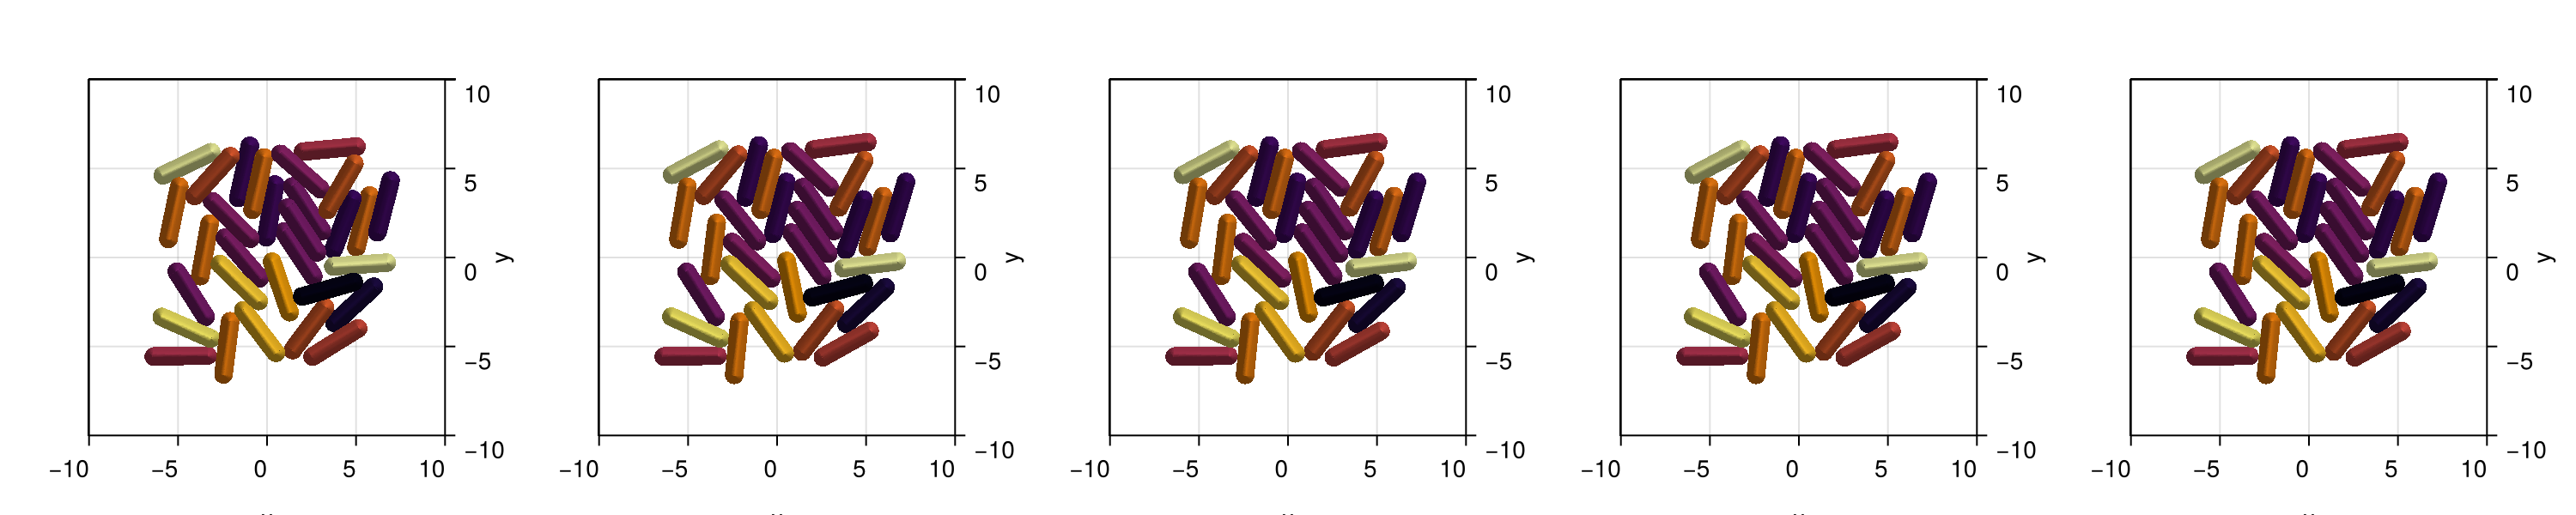

CairoMakie.Screen{IMAGE}


In [12]:
fig = Figure(size=(1500,300))

for (i,j) in enumerate([1:round(Int,length(com)/4):length(com);length(com)])
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com[j][:x],
    com[j][:y],
    com[j][:d],
    com[j][:l],
    com[j][:theta],
    com[j][:theta],
    colorrange = (0, 2*pi)
)

    xlims!(-10,10)
    ylims!(-10,10)
end

display(fig)

In [13]:

function log_community_state(parameters::OrderedDict, t::Int, path::String = "Tods_c.txt")
    # Convert keys to strings so JSON can serialize them
    string_keys = Dict(string(k) => v for (k, v) in parameters)
    # Build entry
    entry = Dict("t" => t, "parameters" => string_keys)
    # Save as a JSON line
    open(path, "a") do io
        println(io, JSON.json(entry))
    end
end


function load_parameters_log(path::String = "Tods_c.txt")
    log = Dict{Int, OrderedDict{Symbol, Any}}()
    for line in eachline(path)
        entry = JSON.parse(line)
        t = entry["t"]
        raw_params = entry["parameters"]
        params = OrderedDict(Symbol(k) => v for (k, v) in raw_params)
        log[t] = params
    end
    times = sort(collect(keys(log)))
    com_array = [log[t] for t in times]
    return com_array, times
end



load_parameters_log (generic function with 2 methods)

## Growth model

We construct over the forces model to add bacterial growth and cell division rules.

In [14]:
function plotMixedAgents2D!(ax, x, y, d, l, angle, type, p; kargs...)
    for (xi, yi, li, di, ai, ti, pi) in zip(x, y, l, d, angle, type, p)


        if ti== 0  # rods
            # colorval = pi
            # colormap = :Blues
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [RGBf(140 /255, 198 /255, 63/255)],
                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color = [RGBf(140 /255, 198 /255, 63/255)],

                # colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color = [RGBf(140 /255, 198 /255, 63/255)],

                kargs...
            )
        else  # puntos
            colorval = pi
            colormap = :Reds
            meshscatter!(ax,
                [xi + li/2 * cos(ai)],
                [yi + li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color =  [RGBf(255 /255, 179 /255, 73/255)],
                kargs...
            )
            meshscatter!(ax,
                [xi - li/2 * cos(ai)],
                [yi - li/2 * sin(ai)];
                marker = Sphere(Point3f(0, 0, 0), Float32(1)),
                markersize = [Point3f(di/2, di/2, di/2)],
                color =  [RGBf(255 /255, 179 /255, 73/255)],
                colormap = colormap,
                kargs...
            )
            meshscatter!(ax,
                [xi],
                [yi];
                marker = Cylinder(Point3f(-.5, 0, 0), Point3f(.5, 0, 0), Float32(1)),
                markersize = [Point3f(li, di/2, di/2)],
                rotation = [ai],
                color =  [RGBf(255 /255, 179 /255, 73/255)],
                colormap = colormap,
                kargs...
            )
        end

    end
    return
end


plotMixedAgents2D! (generic function with 1 method)

In [15]:
rods_PGA = ABM(2,

    agent = Dict(
                :theta=>Float64,
                :d=>Float64,
                :l=>Float64,
                :fx=>Float64,
                :fy=>Float64,
                :W=>Float64,
                :lTarget => Float64,
                :growth=>Float64,
                :Kc => Float64, #Half saturation constant for the medium
                :generation => Int,
                :Vm => Float64,
            ),

    model = Dict(
                :E=>Float64,
                :eta=>Float64,
                :A=>Float64,
                :σlTarget=>Float64,
                :lMax=>Float64,
                :D_c => Float64,
                :beta_c => Float64, #Uptake rate of the cells in the medium
                :D_PGA => Float64, #Decay rate of the cells in the medium
                :alpha_PGA=>Float64, #Decay rate of the cells in the medium
                :beta_PGA=>Float64, #Decay rate of the cells in the medium
                :delta_PGA=>Float64, #Decay rate of the medium
                :Kp => Float64, #Half saturation constant for the medium
                :Kpc => Float64, #Half saturation constant for the medium
                :npc => Int, #Hill coefficient for the medium
                :nu => Float64, 
                :alpha_QS =>Float64,
                :delta_QS =>Float64,
                :D_QS =>Float64,
                :alpha_V =>Float64, 
                :delta_V =>Float64, 
                :beta_V =>Float64, 
                :nV =>Float64, 
                :KVc =>Float64,
                :Kpq => Float64, #Half saturation constant for the medium
                :npq => Int, #Hill coefficient for the medium
                :KpV => Float64, #Half saturation constant for the medium
                :npV => Int, #Hill coefficient for the medium
                :dens0 => Float64,

            ),
    
    medium = Dict(
        :c => Float64,        #Add a medium parameter
        :PGA => Float64,        #Add a medium parameter
        :Hx => Float64,  #Add a medium parameter
        :Hy => Float64,        #Add a medium parameter
        :QS => Float64
    ),

 
    agentODE = quote  
        
        dt(l) = l*growth*c/(Kc+c) 

        fx = 0
        fy = 0
        W = 0
        @loopOverNeighbors i2 begin
            #Use the model provided in the documentation
            Fijx, Fijy, Wij = CBMModels.repulsiveForces_as_rods(x,y,d,l,theta,
                                    x[i2],y[i2],d[i2],l[i2],theta[i2],eta, E, A)

            #Append the repulsive forces
            fx += Fijx
            fy += Fijy
            W += Wij            
        end

        mu_par  = 1/(eta*A)   # μ∥
        mu_perp = A/eta       # μ⊥

        cth=cos(theta)
        sth=sin(theta)

        Fijx= -nu * Hx 
        Fijy= -nu * Hy 
        # Wij = ((xiAux-x)*Fijy - (yiAux-y)*Fijx) * 12. / (eta/A*(l + d)^2)

        fx += (mu_par*cth^2 + mu_perp*sth^2)*Fijx + (mu_par - mu_perp)*cth*sth*Fijy
        fy += (mu_par - mu_perp)*cth*sth*Fijx     + (mu_par*sth^2 + mu_perp*cth^2)*Fijy
        # W += Wij

        #Equations
        dt(x) =  fx 
        dt(y) =  fy 
        dt(theta) =  W
        # dt(Vm) =  alpha_V - Vm*delta_V
        dt(Vm) =  alpha_V - Vm*delta_V - beta_V*1/(1 + (c/KVc)^nV)
    end,

    agentRule = quote #Bound cells

        #Add division
        if l > lTarget
            ww = CBMDistributions.uniform(-1,1)*10 #To add some random torque at division time

            # ww = 0 #To add some random torque at division time
            #Add a new cell
            @addAgent(
                    x=(l+d)/4*cos(theta)+x,
                    y=(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    W=ww,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget),
                    )
            #Add a second cell
            @addAgent(
                    x=-(l+d)/4*cos(theta)+x,
                    y=-(l+d)/4*sin(theta)+y,
                    l=(l-d)/2,
                    lTarget = CBMDistributions.uniform(lMax-σlTarget,lMax+σlTarget), #New target length at which the bactery should divide
                    W=ww)
            #Remove the old cell
            @removeAgent()
        end
        
        c += (-l*beta_c*c/(Kc+c))*dt
        PGA += (alpha_PGA*c^npc/(Kpc^npc+c^npc)*QS^npq/(Kpq^npq+QS^npq)*1/(1+(Vm/KpV)^npV)+ beta_PGA*PGA/(PGA+Kp))*dt
        QS += (alpha_QS)*dt
    end,

    #Medium dynamics with dirichlet conditions and a wall that is as oscillating source of material
    mediumODE=quote 

        if @mediumInside()
            dt(c) =D_c*(@∂2(1,c)+@∂2(2,c))
            dt(PGA) = D_PGA*(@∂2(1,PGA)+@∂2(2,PGA)) - delta_PGA*PGA 
            dt(QS) = D_QS*(@∂2(1,QS)+@∂2(2,QS)) - delta_QS*QS
            Hx = @∂(1,PGA) 
            Hy = @∂(2,PGA)
        elseif @mediumBorder(1,-1) 
            c = dens0*c[2,i2_]
            PGA = 0
            QS = dens0*QS[2,i2_]
        elseif @mediumBorder(1,1)
            c = dens0*c[NMedium[1]-1,i2_]
            PGA = 0
            QS = dens0*QS[NMedium[1]-1,i2_]
        elseif @mediumBorder(2,-1)
            c = dens0*c[i1_,2]
            PGA = 0
            QS = dens0*QS[i1_,2]

        elseif @mediumBorder(2,1)
            c = dens0*c[i1_,NMedium[1]-1]
            PGA = 0
            QS = dens0*QS[i1_,NMedium[1]-1]

        end
    end,

    neighborsAlg=CBMNeighbors.CellLinked(cellEdge=4),
    platform=CPU(),
    agentAlg=CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler(),
);

In [103]:
com = Community(rods_PGA,
            N=1,
            dt=0.0001,
            simBox = [-100 100;-100 100.],
            NMedium=[100,100],
            );


#Natural units scales
m = 1.E3 #g
t = 1/(60*60) # h
d = 1.E6 #um


com.E=5* 1.E5 *m/(t^2*d) #Pa
com.eta = 200 *m/(t^2*d) #Pa h

com.growth = 5.
com.lMax = 4.     
com.σlTarget = 1.5 

com.d = 1.        
com.l = 3.99      
com.lTarget = 4.  
com.x=0
com.y=0
com.theta=0

com.dens0=1


# com.PGA=0
# com.alpha_PGA = 10000
# com.delta_PGA = 100
# com.D_PGA = 50
# com.npc = 1
# com.v = 2.5*10^7
# com.Kpc=0.00001
# com.Kpq=10
# com.npq=10

com.PGA=0
com.alpha_PGA = 100
# com.alpha_PGA = 0
com.delta_PGA = 10
com.beta_PGA = 0
com.Kp = 0.2
com.D_PGA = 2.5
com.npc = 1
com.nu = 2.5*10^9
com.Kpc= 5E-5
com.Kpq=1.5
com.npq=10

com.D_c = 1000
# com.cm = 1 #Medium concentration
com.c = 1
com.Kc = 1 #Half saturation constant for the medium
com.beta_c = 20 

# com.Vm = -149
# com.alpha_V = -150
# com.delta_V = 1
# com.beta_V = 100
# com.KVc = 5E-4
# com.nV = 10


com.Vm = -1
com.alpha_V = -1.
com.delta_V = 1
com.beta_V = 2.

com.KVc = 5E-3
com.nV = 10


com.KpV = 2
com.npV = 10

com.QS=0
com.alpha_QS = 1.
com.delta_QS = 0.05
com.D_QS = 500 

com.A=0.3




0.3

In [104]:
open("Tods_c.txt", "w") do f
    # clear file at start
end

In [ ]:
prev_steps=Int(round(0/com.dt))
steps=Int(round(25/com.dt))
saveEach = Int(round(1/com.dt))/10
N=com.N*4

loadToPlatform!(com,preallocateAgents=N)

step=prev_steps
log_community_state(com.parameters, step)


while (step<steps+1) & (com.N < 1500)
    
    step!(com)

    if step % saveEach == 0
        bringFromPlatform!(com)
        if N - com.N[1] <= 0
                println("Step ",step, " N: ", com.N[1], " preallocateAgents: ", N)
                @warn "More agents than preallocateAgents, stopping simulation."
                break
        elseif   N - com.N[1]  < 4*com.N[1]
                N = 15*com.N[1]
        end 
        println("Step ",step, " N: ", com.N[1])
        log_community_state(com.parameters, step)
        loadToPlatform!(com,preallocateAgents=N)
    end
    step += 1
end
bringFromPlatform!(com)

Step 0 N: 1
Step 1000 N: 2
Step 2000 N: 2
Step 3000 N: 2
Step 4000 N: 3
Step 5000 N: 3
Step 6000 N: 4
Step 7000 N: 5
Step 8000 N: 7
Step 9000 N: 7
Step 10000 N: 8
Step 11000 N: 8
Step 12000 N: 11
Step 13000 N: 13
Step 14000 N: 15
Step 15000 N: 16
Step 16000 N: 16
Step 17000 N: 19
Step 18000 N: 22
Step 19000 N: 25
Step 20000 N: 29
Step 21000 N: 31
Step 22000 N: 33
Step 23000 N: 35
Step 24000 N: 36
Step 25000 N: 41
Step 26000 N: 48
Step 27000 N: 55
Step 28000 N: 57
Step 29000 N: 64
Step 30000 N: 65
Step 31000 N: 70
Step 32000 N: 75
Step 33000 N: 81
Step 34000 N: 84
Step 35000 N: 90
Step 36000 N: 96
Step 37000 N: 105
Step 38000 N: 112
Step 39000 N: 116
Step 40000 N: 120
Step 41000 N: 122
Step 42000 N: 131
Step 43000 N: 136
Step 44000 N: 143
Step 45000 N: 146
Step 46000 N: 147
Step 47000 N: 149
Step 48000 N: 156
Step 49000 N: 161
Step 50000 N: 169
Step 51000 N: 171
Step 52000 N: 179
Step 53000 N: 183
Step 54000 N: 188
Step 55000 N: 196
Step 56000 N: 203
Step 57000 N: 209
Step 58000 N: 216


In [ ]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    )

    xlims!(-50,50)
    ylims!(-50,50)
end

Colorbar(fig[1, length(js) + 1],
    colormap = Reverse(:inferno),
    colorrange = (-4, 0),
    label = "V"
)
display(fig)

In [ ]:
com.Vm

In [ ]:
minimum(com.Vm)

In [ ]:
com_load,times=load_parameters_log("Tods_c.txt")
fig = Figure(size=(2000,500))

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
# js =  length(com_load)
js = round.(Int, range(1, length(com_load), length=4))
for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                xticksvisible=false,
                yticksvisible=false,
                xticklabelsvisible=false,
                yticklabelsvisible=false,
                xlabelvisible=false,
                ylabelvisible=false

            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    label = "V"
)
display(fig)

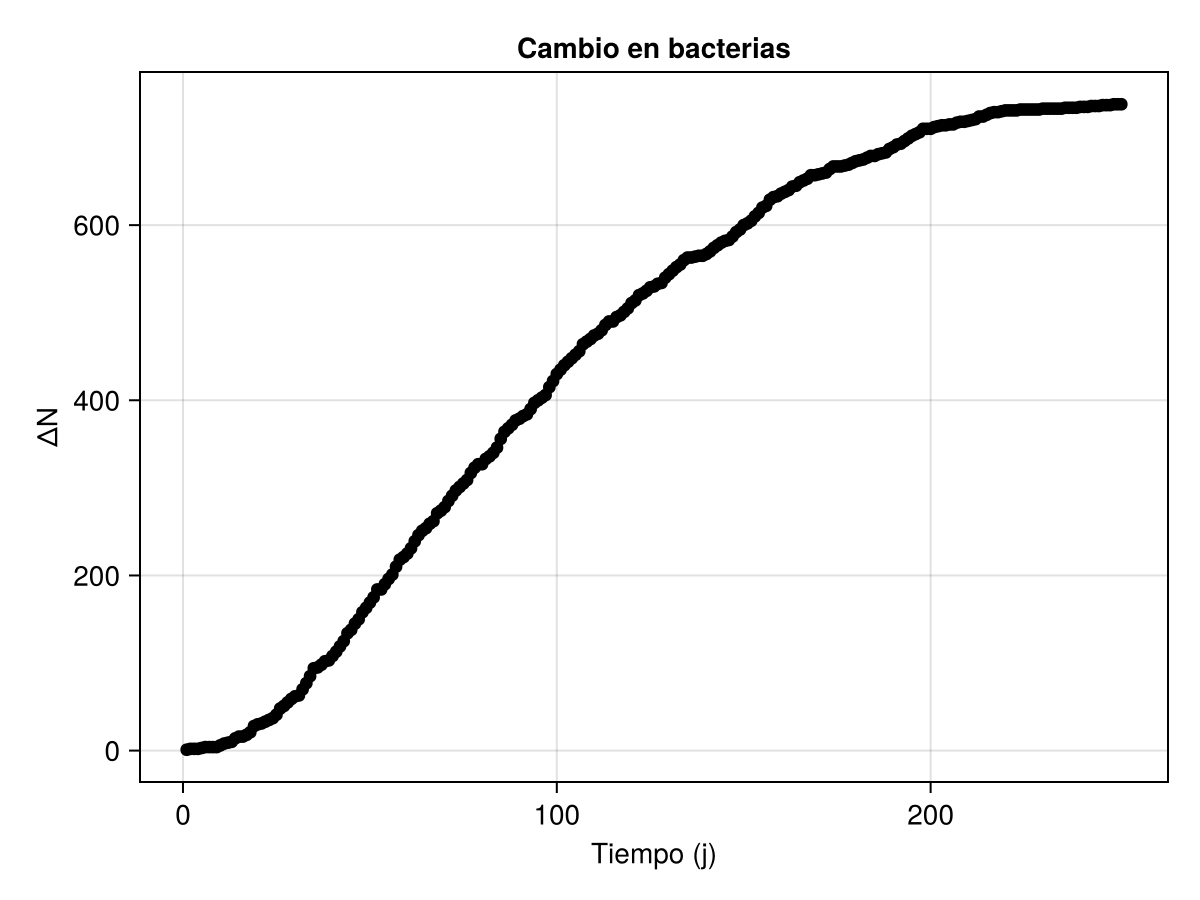

In [96]:
# Extraemos N
N = [length(com_load[j][:x]) for j in 1:length(com_load)]
P = [maximum(maximum(com_load[j][:PGA])) for j in 1:length(com_load)]
Q = [maximum(maximum(com_load[j][:QS])) for j in 1:length(com_load)]
V = [minimum(minimum(com_load[j][:Vm])) for j in 1:length(com_load)]
C = [minimum(minimum(com_load[j][:c])) for j in 1:length(com_load)]

# Diferencia entre tiempos consecutivos
dN = diff(N)

# Eje temporal (para diff hay un punto menos)
t = 1:length(N)

# Figura y ejes
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "Tiempo (j)", ylabel = "ΔN", title = "Cambio en bacterias")

# Scatter plot
scatter!(ax, t, N, color = :black)


fig

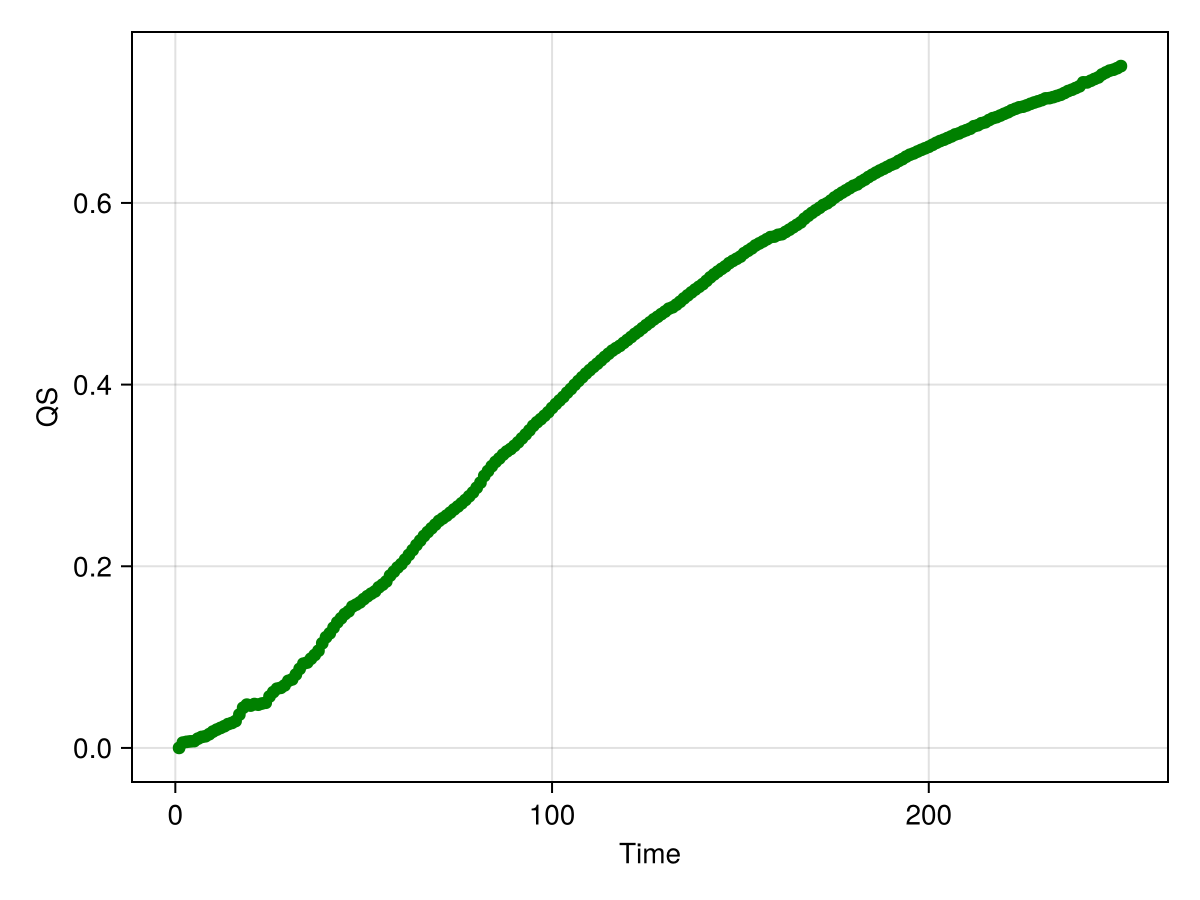

In [77]:
# Figura y ejes
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "Time", ylabel = "QS")

# Scatter plot
scatter!(ax, t, Q, color = :green)
fig

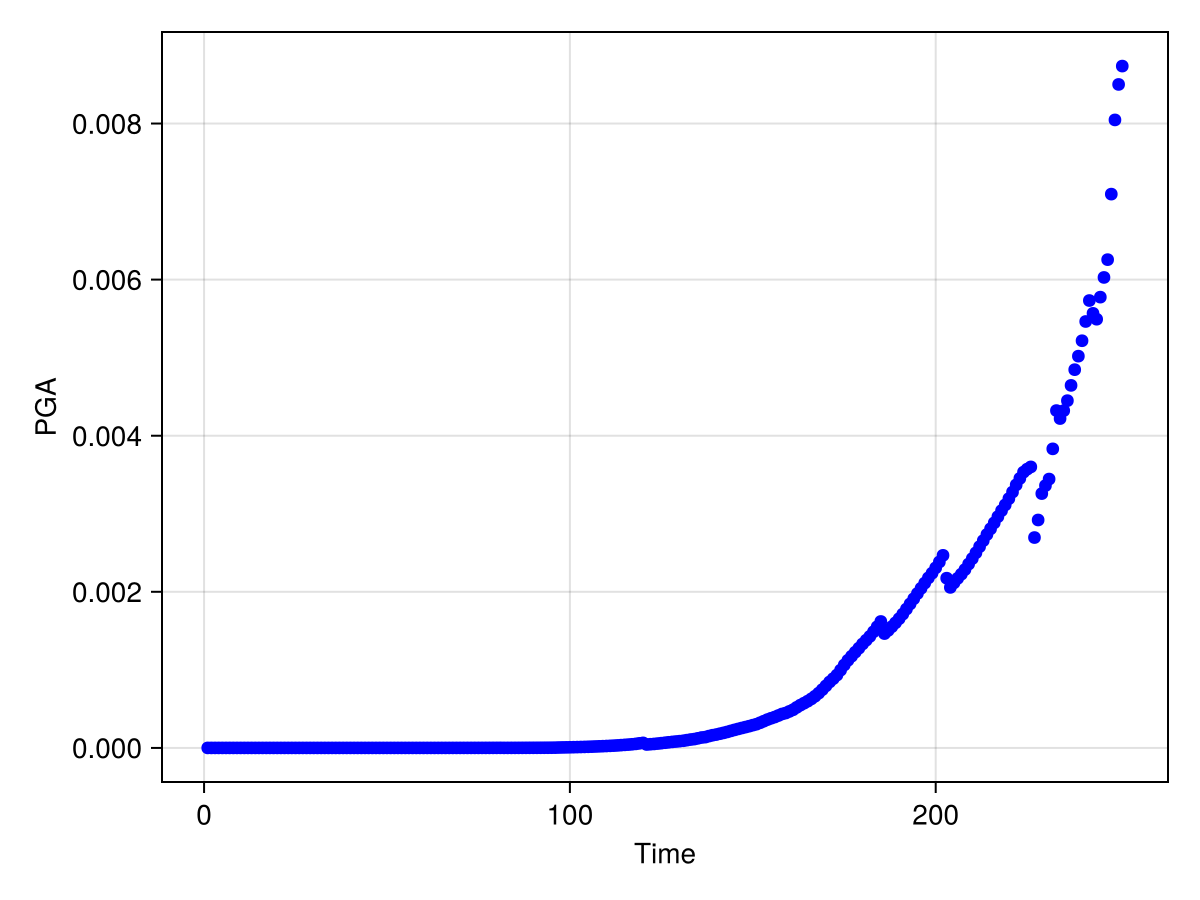

In [78]:
# Figura y ejes
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "Time", ylabel = "PGA")

# Scatter plot
scatter!(ax, t, P, color = :blue)
fig

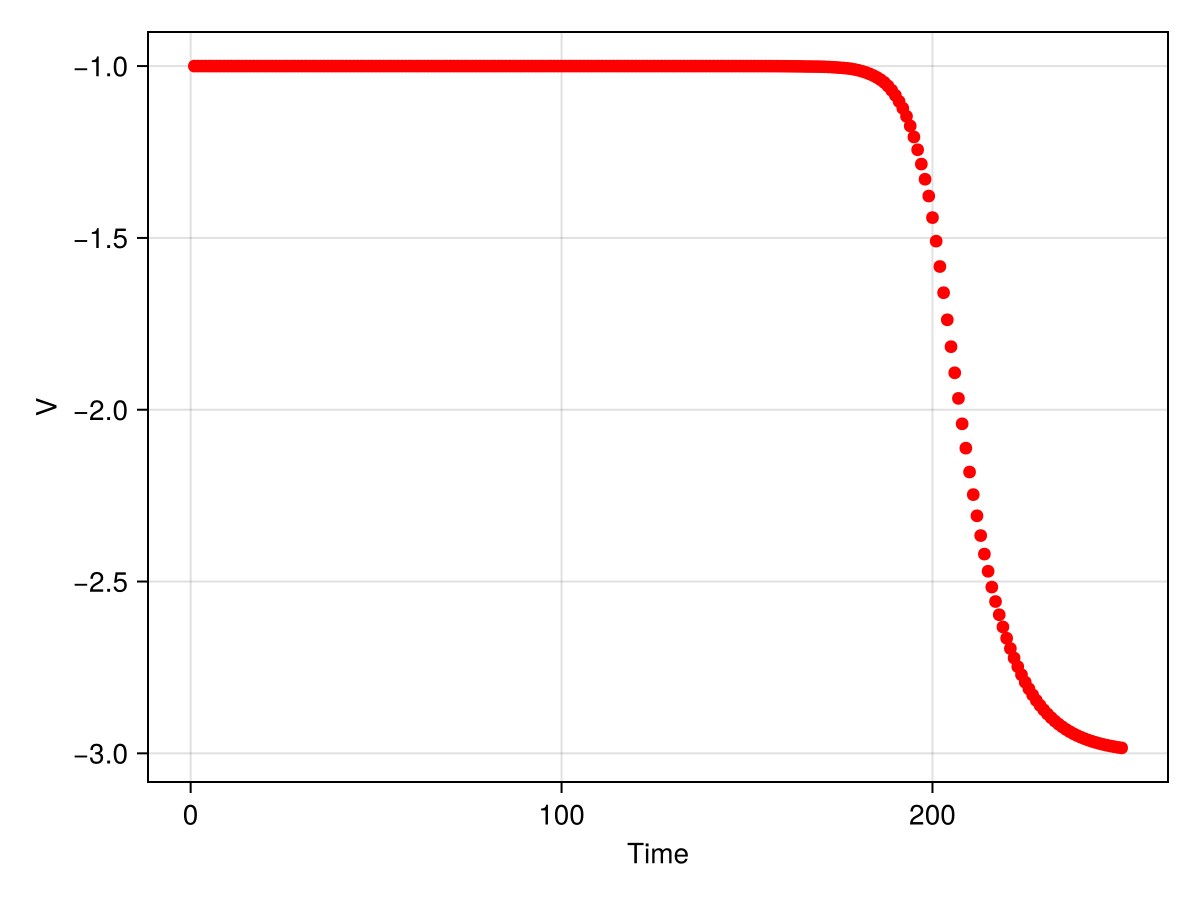

In [79]:
# Figura y ejes
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "Time", ylabel = "V")

# Scatter plot
scatter!(ax, t, V, color = :red)
fig

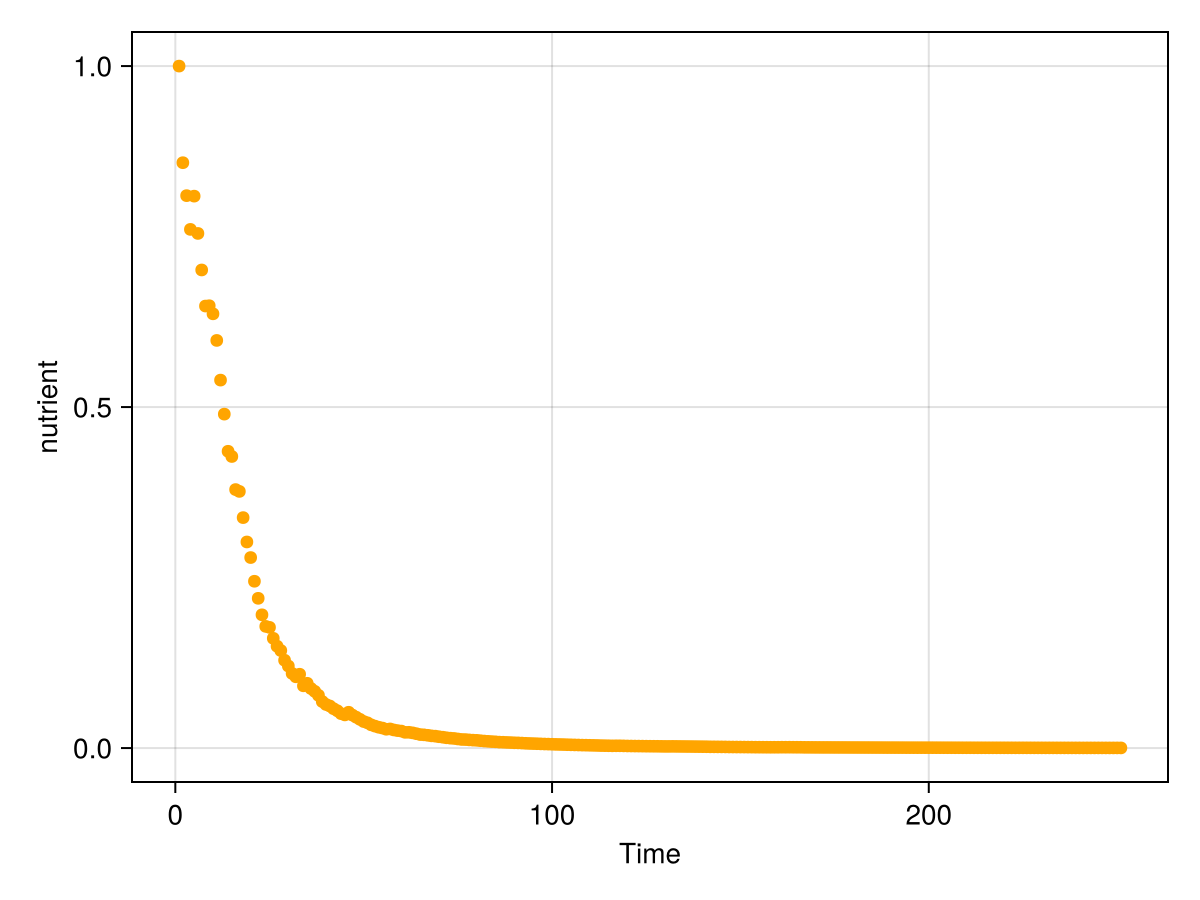

In [80]:
# Figura y ejes
fig = Figure()
ax = Axis(fig[1, 1], xlabel = "Time", ylabel = "nutrient")

# Scatter plot
scatter!(ax, t, C, color = :orange)
fig

In [102]:
com_load[100][:c][50][50]

0.004076278693593504

In [98]:
minimum(com.c)

1.7659250341667133e-5

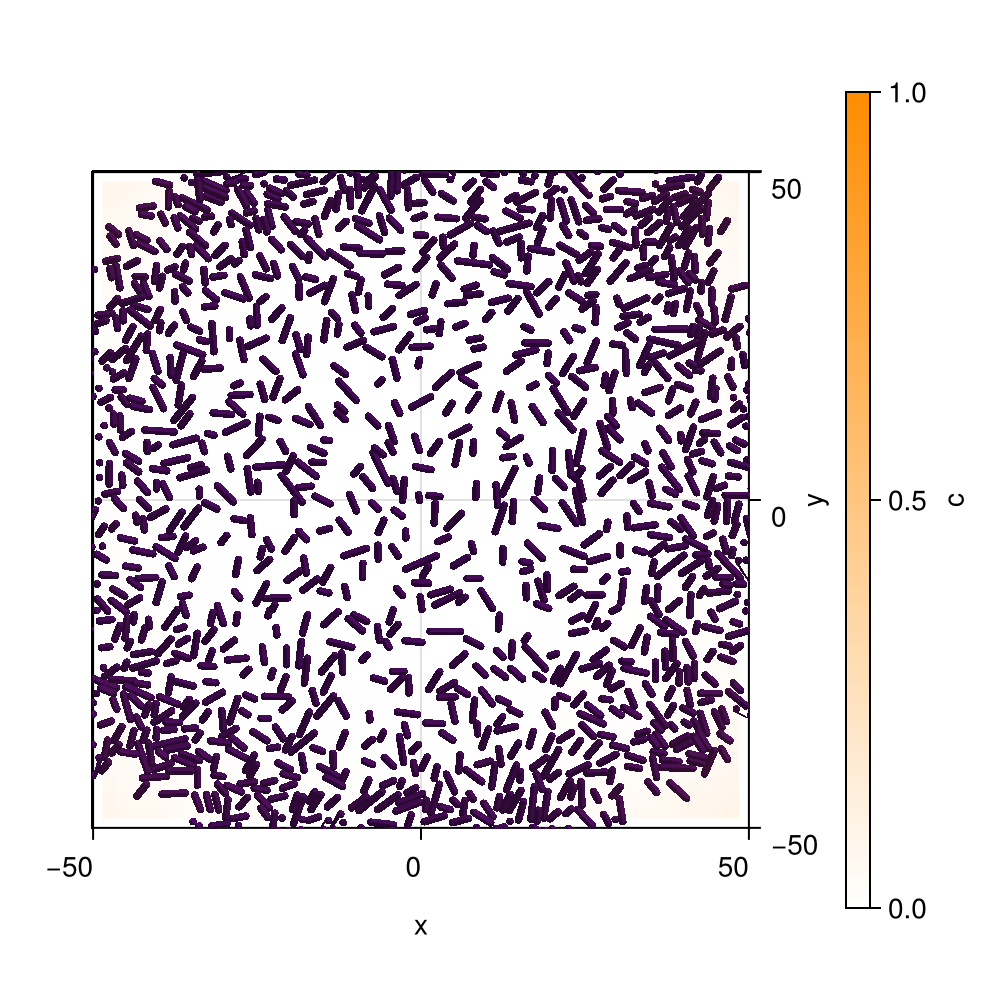

CairoMakie.Screen{IMAGE}


In [27]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:c]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
            Float64.(hcat(com_load[j][:c]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)
display(fig)

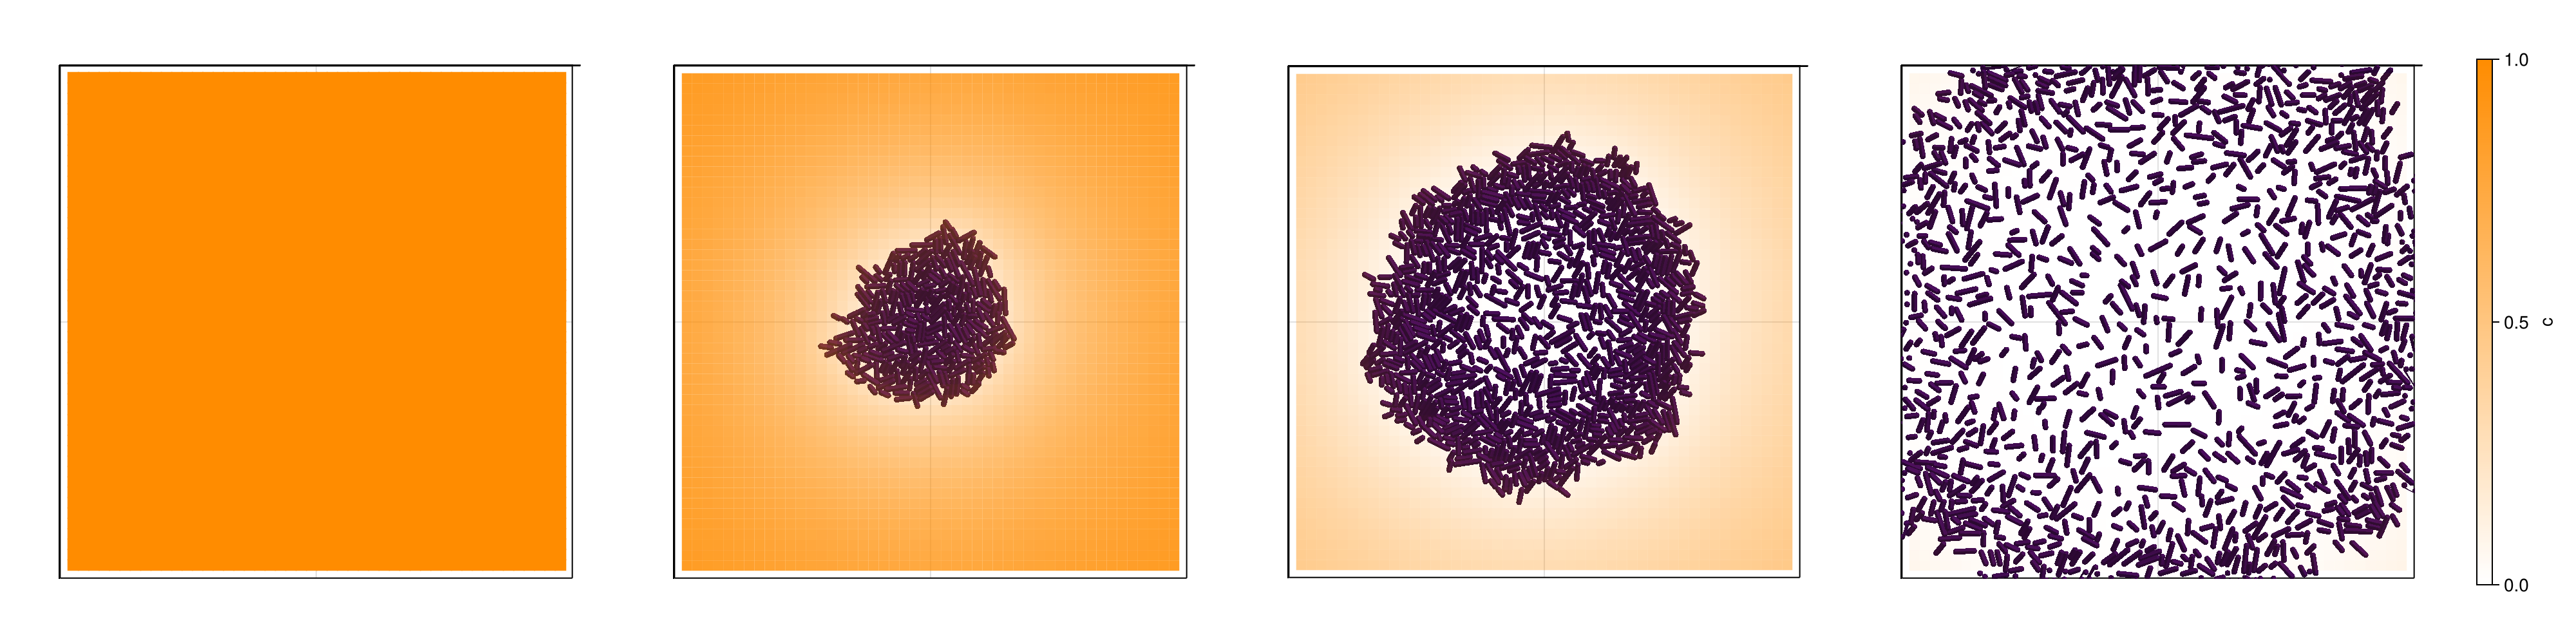

CairoMakie.Screen{IMAGE}


In [28]:
com_load,times=load_parameters_log("Tods_c.txt")
fig = Figure(size=(2000,500))

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
# js =  length(com_load)
js = round.(Int, range(1, length(com_load), length=4))
for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                xticksvisible=false,
                yticksvisible=false,
                xticklabelsvisible=false,
                yticklabelsvisible=false,
                xlabelvisible=false,
                ylabelvisible=false

            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    )

    m2 = heatmap!(ax,
        range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.c)[1]),
        range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.c)[1]),
        Float64.(hcat(com_load[j][:c]...)),
        colormap = colormap_c,
        colorrange = colorrange_c
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "c"
)

display(fig)

In [29]:
com.c[50,50], com.c[50,40]

(0.0015063142000955312, 0.002631430711980143)

In [30]:
maximum(com.QS)

1.226312705265133

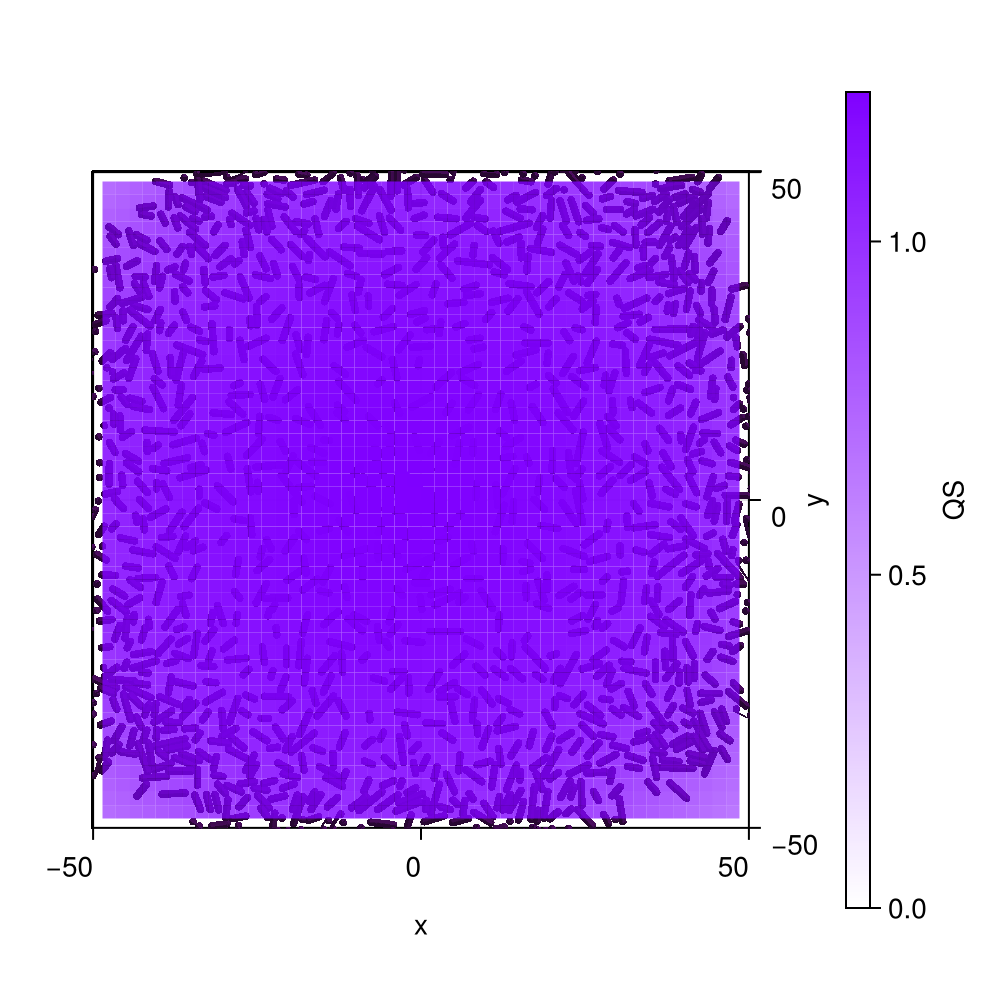

CairoMakie.Screen{IMAGE}


In [31]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(0.5, 0, 1, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(0.5, 0, 1, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:QS]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:QS]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.QS)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.QS)[1]),
            Float64.(hcat(com_load[j][:QS]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "QS"
)
display(fig)

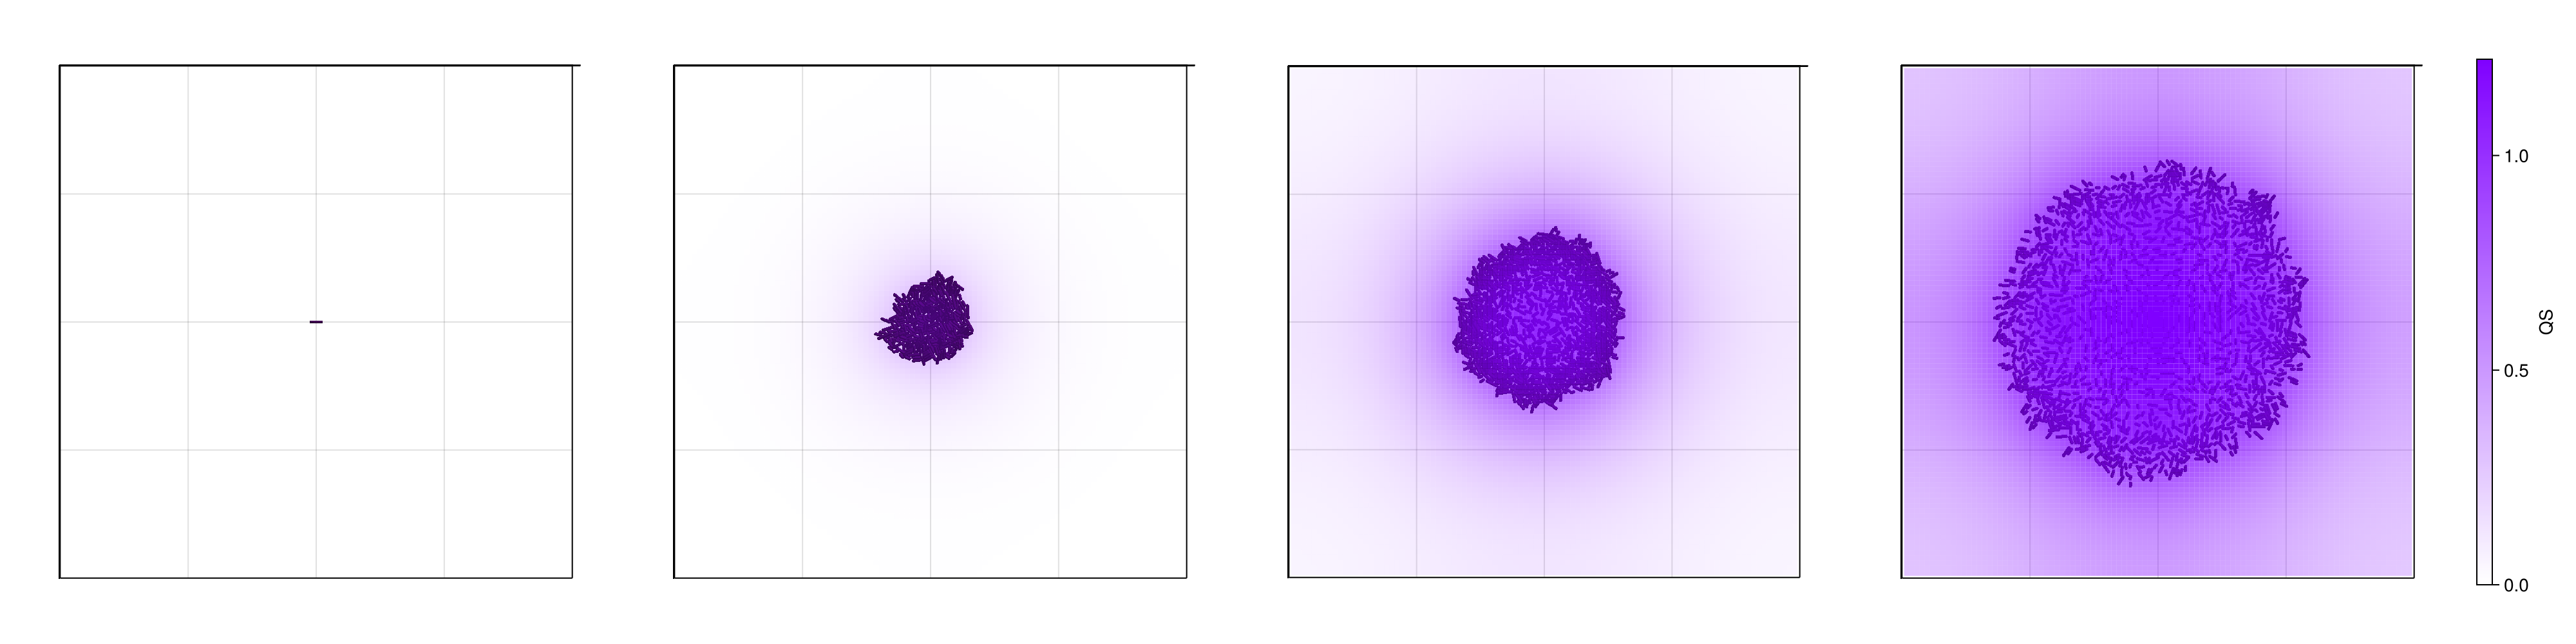

CairoMakie.Screen{IMAGE}


In [32]:
com_load,times=load_parameters_log("Tods_c.txt")
fig = Figure(size=(2000,500))

cmap_transp_orange = cgrad(
    [RGBAf(0.5, 0, 1, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(0.5, 0, 1, 1.0)],  # verde con alfa 1 (opaco)
    506
)
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:QS]), com_load)))

colormap_c=cmap_transp_orange

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
# js =  length(com_load)
js = round.(Int, range(1, length(com_load), length=4))
for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                xticksvisible=false,
                yticksvisible=false,
                xticklabelsvisible=false,
                yticklabelsvisible=false,
                xlabelvisible=false,
                ylabelvisible=false

            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    )

    m2 = heatmap!(ax,
        range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.QS)[1]),
        range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.QS)[1]),
        Float64.(hcat(com_load[j][:QS]...)),
        colormap = colormap_c,
        colorrange = colorrange_c
    )

    xlims!(-100,100)
    ylims!(-100,100)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "QS"
)

display(fig)

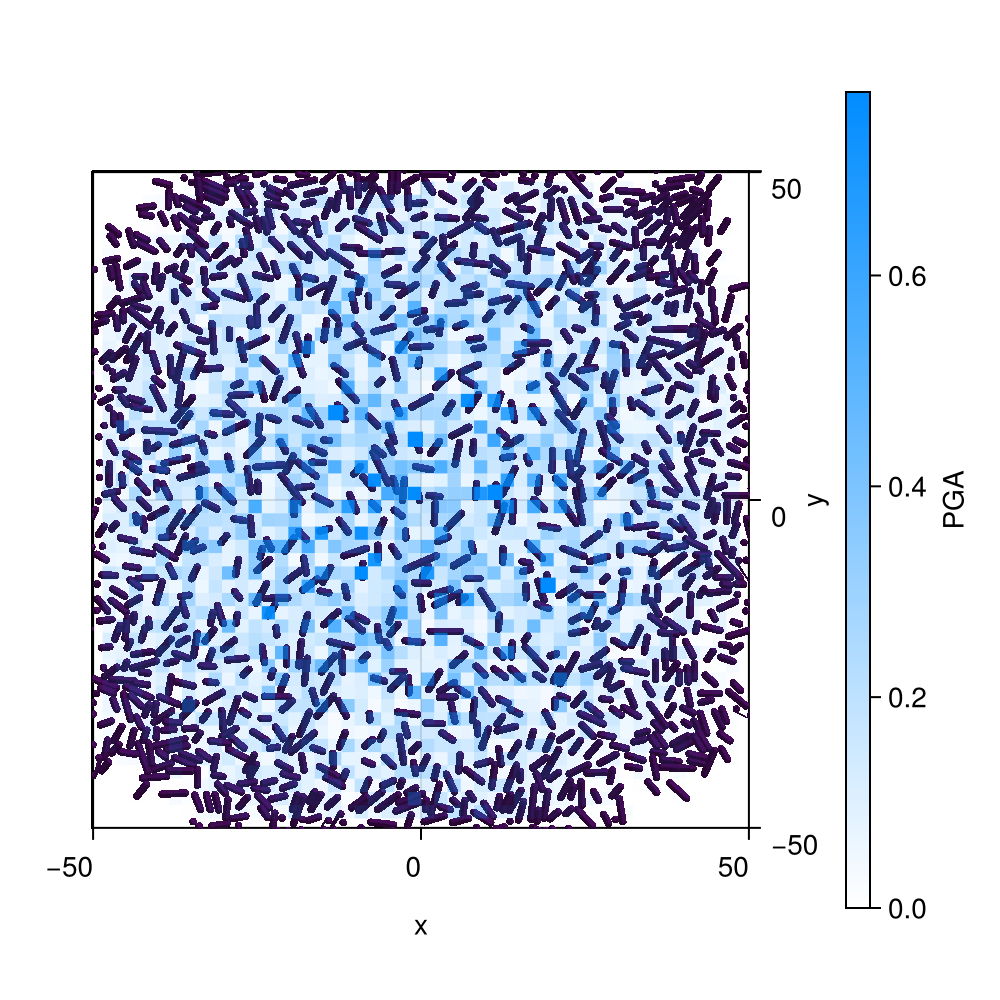

CairoMakie.Screen{IMAGE}


In [33]:
com_load,times=load_parameters_log("Tods_c.txt")
simBox_cpu = Array(com.simBox)  # copia a CPU

cmap_transp_orange = cgrad(
    [RGBAf(0.0, 0.55, 1, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(0.0, 0.55, 1, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange
# colormap_c=:Oranges
# colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))

fig = Figure(size=(500,500))

js =  length(com_load)

for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false
            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    )

    m2 = heatmap!(ax,
            range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
            range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
            Float64.(hcat(com_load[j][:PGA]...)),
            colormap = colormap_c,
            colorrange = colorrange_c
        )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "PGA"
)
display(fig)

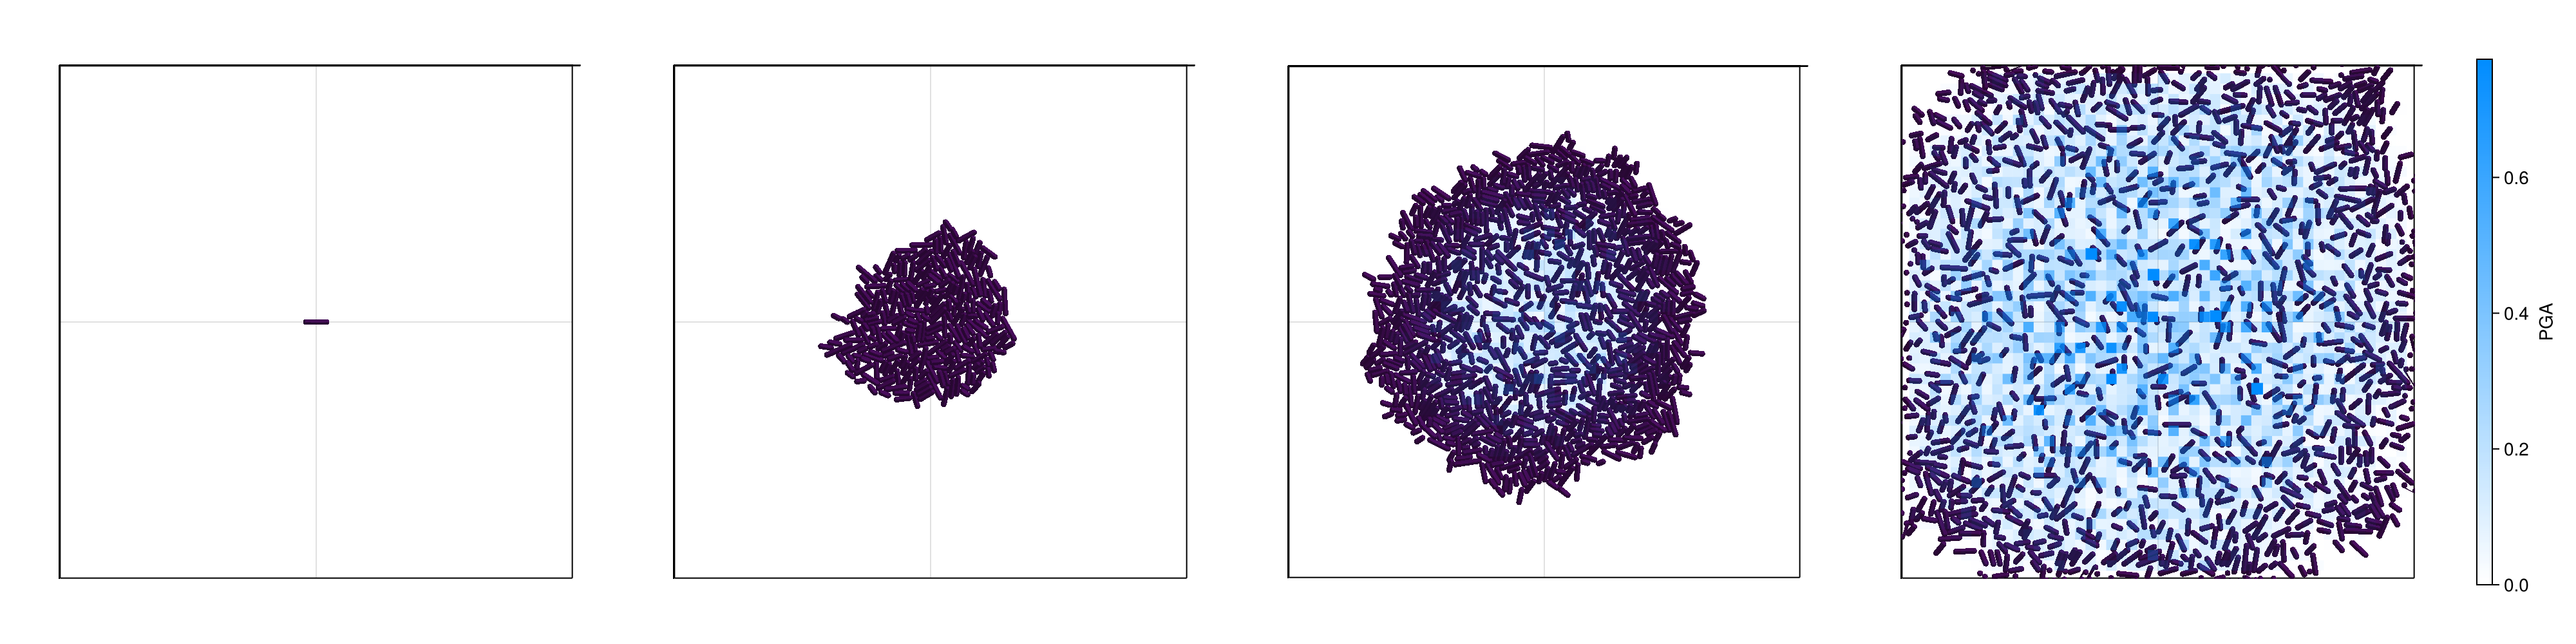

CairoMakie.Screen{IMAGE}


In [34]:
com_load,times=load_parameters_log("Tods_c.txt")
fig = Figure(size=(2000,500))

cmap_transp_orange = cgrad(
    [RGBAf(0.0, 0.55, 1, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(0.0, 0.55, 1, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))

# js = [1:round(Int, length(com_load)/4):length(com_load); length(com_load)]
# js =  length(com_load)
js = round.(Int, range(1, length(com_load), length=4))
for (i,j) in enumerate(js)
    ax = Axis3(fig[1,i],
                azimuth=3*π/2,
                elevation=π/2,
                zlabelvisible=false,
                zticklabelsvisible=false,
                zgridvisible=false,
                zspinesvisible=false,
                xticksvisible=false,
                yticksvisible=false,
                xticklabelsvisible=false,
                yticklabelsvisible=false,
                xlabelvisible=false,
                ylabelvisible=false

            )

    plotAgents2D!(
    ax,
    com_load[j][:x],
    com_load[j][:y],
    com_load[j][:d],
    com_load[j][:l],
    com_load[j][:theta],
    com_load[j][:Vm],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    )

    m2 = heatmap!(ax,
        range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
        range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
        Float64.(hcat(com_load[j][:PGA]...)),
        colormap = colormap_c,
        colorrange = colorrange_c
    )

    xlims!(-50,50)
    ylims!(-50,50)
end
Colorbar(fig[1, length(js) + 1],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "PGA"
)

display(fig)

In [40]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())
hidedecorations!(ax)     # oculta ticks, etiquetas y más
ax.xgridvisible = true
ax.ygridvisible = true

# colorrange = (0.0,  maximum(maximum(p -> maximum(p[:generation]), com_load)))
colorrange = (0.0,  2.)

Colorbar(fig[1, 2],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    label = "V"
)


Makie.record(fig, "Colony.mp4", 1:5:Int(length(com_load)); framerate = 10) do j
 
    Makie.empty!(ax)
   
    plotAgents2D!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        # com_load[j][:type],
        com_load[j][:Vm],
        colormap = Reverse(:inferno),
        colorrange =  (-4 , 0),
    )


    # xlims!(ax, - (com_load[j][:rmax][1]+5), com_load[j][:rmax][1]+5)
    # ylims!(ax, - (com_load[j][:rmax][1]+5),  com_load[j][:rmax][1]+5)
    # xlims!(ax, - (com.rmax[1]+5), com.rmax[1]+5)
    # ylims!(ax, - (com.rmax[1]+5),  com.rmax[1]+5)
    xlims!(ax, - (50), 50)
    ylims!(ax, - (50),  50)
end


"Colony.mp4"

In [41]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())
hidedecorations!(ax)     # oculta ticks, etiquetas y más
ax.xgridvisible = true
ax.ygridvisible = true

cmap_transp_orange = cgrad(
    [RGBAf(1.0, 0.55, 0.0, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(1.0, 0.55, 0.0, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:QS]), com_load)))


Colorbar(fig[1, 2],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    label = "V"
)
Colorbar(fig[1, 3],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "QS"
)

Makie.record(fig, "Colony_QS.mp4", 1:5:Int(length(com_load)); framerate = 10) do j
 
    Makie.empty!(ax)


   
    plotAgents2D!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        # com_load[j][:type],
        com_load[j][:Vm],
        colormap = Reverse(:inferno),
        colorrange =  (-4 , 0),
    )

    m2 = heatmap!(ax,
        range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.QS)[1]),
        range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.QS)[1]),
        Float64.(hcat(com_load[j][:QS]...)),
        colormap = colormap_c,
        colorrange = colorrange_c
    )

    # xlims!(ax, - (com_load[j][:rmax][1]+5), com_load[j][:rmax][1]+5)
    # ylims!(ax, - (com_load[j][:rmax][1]+5),  com_load[j][:rmax][1]+5)
    # xlims!(ax, - (com.rmax[1]+5), com.rmax[1]+5)
    # ylims!(ax, - (com.rmax[1]+5),  com.rmax[1]+5)
    xlims!(ax, - (50), 50)
    ylims!(ax, - (50),  50)
end


"Colony_QS.mp4"

In [42]:

# Crear figura y ejes
fig = Figure(size = (800, 600))
grid = fig[1, 1] = GridLayout()
ax = Axis(grid[1, 1]; aspect = DataAspect())
hidedecorations!(ax)     # oculta ticks, etiquetas y más
ax.xgridvisible = true
ax.ygridvisible = true

cmap_transp_orange = cgrad(
    [RGBAf(0.0, 0.55, 1, 0.0),   # verde con alfa 0 (transparente)
     RGBAf(0.0, 0.55, 1, 1.0)],  # verde con alfa 1 (opaco)
    506
)

colormap_c=cmap_transp_orange
colorrange_c = (0.0,  maximum(maximum(p -> maximum(p[:PGA]), com_load)))


Colorbar(fig[1, 2],
    colormap = Reverse(:inferno),
    colorrange =  (-4, 0),
    label = "V"
)
Colorbar(fig[1, 3],
    colormap = colormap_c,
    colorrange = colorrange_c,
    label = "PGA"
)

Makie.record(fig, "Colony_PGA.mp4", 1:5:Int(length(com_load)); framerate = 10) do j
 
    Makie.empty!(ax)

    m2 = heatmap!(ax,
        range(simBox_cpu[1,1],simBox_cpu[1,2],length=size(com.PGA)[1]),
        range(simBox_cpu[2,1],simBox_cpu[2,2],length=size(com.PGA)[1]),
        Float64.(hcat(com_load[j][:PGA]...)),
        colormap = colormap_c,
        colorrange = colorrange_c
    )
   
    plotAgents2D!(
        ax,
        com_load[j][:x],
        com_load[j][:y],
        com_load[j][:d],
        com_load[j][:l],
        com_load[j][:theta],
        # com_load[j][:type],
        com_load[j][:Vm],
        colormap = Reverse(:inferno),
        colorrange =  (-4 , 0),
    )


    # xlims!(ax, - (com_load[j][:rmax][1]+5), com_load[j][:rmax][1]+5)
    # ylims!(ax, - (com_load[j][:rmax][1]+5),  com_load[j][:rmax][1]+5)
    # xlims!(ax, - (com.rmax[1]+5), com.rmax[1]+5)
    # ylims!(ax, - (com.rmax[1]+5),  com.rmax[1]+5)
    xlims!(ax, - (50), 50)
    ylims!(ax, - (50),  50)
end


"Colony_PGA.mp4"